<a href="https://colab.research.google.com/github/avgvstinee/python-ml-essentials/blob/main/Simple_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [41]:
# Create a simple neural network
class Net(nn.Module):
  # Input layer ( 4 features of the flower) ---->
  # Hidden Layer1 (number of neurons). ---->
  # H2 (n) ---->
  # output layer ( 3 classes of iris flower)

  def __init__(self,in_channels=4, hidden_layer1=8,hidden_layer2=9,out_channels=3):
    super().__init__() # instantiate our nn.Modeule
    self.fc1 = nn.Linear(in_channels,hidden_layer1)
    self.fc2 = nn.Linear(hidden_layer1,hidden_layer2)
    self.out = nn.Linear(hidden_layer2,out_channels)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)


    return x


In [42]:
# Pick a manual seed for randomization
torch.manual_seed(41)

# create an instance of the model
model = Net()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [45]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [46]:
# Change last column from strings to integers
my_df['species'] = my_df['species'].replace('setosa',0.0)
my_df['species'] = my_df['species'].replace('versicolor',1.0)
my_df['species'] = my_df['species'].replace('virginica',2.0)
my_df


/tmp/ipykernel_6609/1378246165.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica',2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [47]:
# Train Test Split | Set X , y
X = my_df.drop('species', axis=1)
y = my_df['species']

In [48]:
# Convert these to numpy arrays
X = X.values
y = y.values

In [49]:
from sklearn.model_selection import train_test_split


In [50]:
# Train Test Split

In [51]:
X_train, X_test , y_train , y_test = train_test_split(X, y , test_size=0.2, random_state=41)

In [52]:
# Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [53]:
# Convert X labels to long tensors
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [54]:
# Set the criterion of model to measure the error , how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer , lr = learning rate ( if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=0.01)

In [55]:
# Train our model
# Epochs? (one run through all the training data in our network)
epochs = 100
losses = [ ]

for epoch in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # Get predicted results

  # Measure a loss/ error , (it is going to be high at first)
  loss = criterion(y_pred, y_train) # predicted values vs the y_train values

  # Keep track of our losses
  losses.append(loss.detach().numpy())

  # print every 10  epoch
  if epoch % 10 == 0:
    print(f'Epoch: {epoch} and loss : {loss}')

  # Do some some back propagation : take the error rate forward propagation and feed it back
  # through the network  to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss : 1.1251550912857056
Epoch: 10 and loss : 1.0096259117126465
Epoch: 20 and loss : 0.8157405853271484
Epoch: 30 and loss : 0.585706353187561
Epoch: 40 and loss : 0.3999636471271515
Epoch: 50 and loss : 0.2676880657672882
Epoch: 60 and loss : 0.17942363023757935
Epoch: 70 and loss : 0.12151690572500229
Epoch: 80 and loss : 0.0860118418931961
Epoch: 90 and loss : 0.06520850956439972


Text(0.5, 0, 'Epoch')

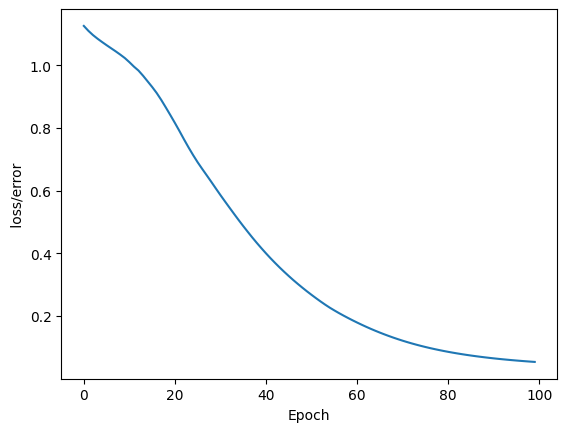

In [56]:
# Graph it out
plt.plot(range(epochs), losses)
plt.ylabel(" loss/error ")
plt.xlabel('Epoch')

In [57]:
# Evaluate Model on Test Data Set (validate model on test set)
with torch.no_grad():    # Basically turn off back propagation
  y_eval = model.forward(X_test) # X_test are features from our  test set , y_eval will be predictions
  loss - criterion(y_eval, y_test)

In [58]:
loss

tensor(0.0538, grad_fn=<NllLossBackward0>)

In [59]:
correct = 0
with torch.no_grad():
  for i , data in enumerate(X_test):
    y_val = model.forward(data)

    # This will tell us what type of flower class our network thinks it is

    print(f'{i + 1}  {str(y_val)} \t {y_test[i]}')


    # Correct or not

    if y_val.argmax().item() == y_test[i]:
      correct +=1


  print(f'We got {correct} correct')


1  tensor([-5.8760,  4.4628,  6.5124]) 	 2
2  tensor([-7.5436,  4.1670,  9.7255]) 	 2
3  tensor([-8.4504,  5.1271, 10.1987]) 	 2
4  tensor([-4.3398,  5.6267,  2.5608]) 	 1
5  tensor([-7.1825,  4.8754,  8.2992]) 	 2
6  tensor([-3.3974,  5.3463,  1.2803]) 	 1
7  tensor([-5.9231,  4.9822,  5.9997]) 	 2
8  tensor([-4.2881,  5.7003,  2.3889]) 	 1
9  tensor([-6.5356,  4.9257,  7.1260]) 	 2
10  tensor([-8.0509,  4.4129, 10.3286]) 	 2
11  tensor([-5.6762,  4.9500,  5.6215]) 	 2
12  tensor([ 4.5662, -2.2476, -2.8911]) 	 0
13  tensor([ 4.2571, -1.9967, -2.7330]) 	 0
14  tensor([-2.1108,  4.0515,  0.5799]) 	 1
15  tensor([ 3.4575, -1.2098, -2.3514]) 	 0
16  tensor([-5.4724,  5.1165,  5.0934]) 	 2
17  tensor([ 4.0557, -1.7949, -2.6492]) 	 0
18  tensor([-5.8075,  4.6053,  6.2458]) 	 1
19  tensor([ 4.4343, -2.1392, -2.8242]) 	 0
20  tensor([ 3.4527, -1.2514, -2.3660]) 	 0
21  tensor([-2.6189,  4.5619,  0.8574]) 	 1
22  tensor([-7.7412,  4.7377,  9.4199]) 	 2
23  tensor([ 3.5743, -1.3221, -2.4135]) 	

In [60]:
#Evaluate NEW Data on the Network
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [61]:
with torch.no_grad():
  print(model(new_iris))

tensor([ 4.5365, -2.2383, -2.8684])


In [62]:
# Save and Load the our NN Model

torch.save(model.state_dict(), 'first_iris_model.pt')


In [64]:
# Load and Saved Model
new_model = Net()
new_model.load_state_dict(torch.load('first_iris_model.pt'))

<All keys matched successfully>

In [65]:
# make sure it is loaded correctly
new_model.eval()

Net(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)